In [2]:
# ============================================================
# 1 — Imports y carga de datos
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

VERDE  = '#2D6A4F'
VERDE2 = '#40916C'
VERDE3 = '#74C69D'
AMBER  = '#E9C46A'
CORAL  = '#E76F51'
GRIS   = '#6C757D'

BASE   = r"C:\Users\Usuario\Coffe-ops-eda-analysis\data\processed" + "\\"
OUTPUT = r"C:\Users\Usuario\Coffe-ops-eda-analysis\output" + "\\"

print("Cargando datos...")
df_items  = pd.read_csv(BASE + "items_clean.csv")
print("  items_clean OK")
df_trans  = pd.read_csv(BASE + "transacciones_clean.csv")
print("  transacciones_clean OK")
df_conteo = pd.read_csv(BASE + "items_conteo_clean.csv")
print("  items_conteo_clean OK")
df_secc   = pd.read_csv(BASE + "secciones_clean.csv")
print("  secciones_clean OK")

# Parsear fechas después de cargar
df_items['fecha'] = pd.to_datetime(df_items['fecha'])
df_trans['fecha'] = pd.to_datetime(df_trans['fecha'])
print("  Fechas parseadas OK")

# Preparar df_menu
EXCLUIR = ['Tiramisu stevia x 20', 'Ley Redondeo',
           'Korone pan (Oferta por Unidad)']
df_menu = df_conteo[~df_conteo['producto'].isin(EXCLUIR)].copy()
df_menu['cantidad']        = pd.to_numeric(df_menu['cantidad'],        errors='coerce')
df_menu['total']           = pd.to_numeric(df_menu['total'],           errors='coerce')
df_menu['n_transacciones'] = pd.to_numeric(df_menu['n_transacciones'], errors='coerce')
df_menu = df_menu.dropna(subset=['cantidad','total']).copy()
df_menu['precio_promedio'] = df_menu['total'] / df_menu['cantidad']
print("  df_menu preparado OK")

print(f"\nDatos cargados correctamente")
print(f"  Productos para análisis de menú: {len(df_menu)}")
print(f"  Ingresos totales del menú: ${df_menu['total'].sum():,.0f} CLP")

Cargando datos...
  items_clean OK
  transacciones_clean OK
  items_conteo_clean OK
  secciones_clean OK
  Fechas parseadas OK
  df_menu preparado OK

Datos cargados correctamente
  Productos para análisis de menú: 157
  Ingresos totales del menú: $72,717,142 CLP


In [3]:
# ============================================================
# 2 — Estadística descriptiva de variables clave
# ============================================================
print("=" * 60)
print("ESTADÍSTICA DESCRIPTIVA — VARIABLES OPERACIONALES")
print("=" * 60)

variables = {
    'Ticket por transacción (CLP)': df_trans['total'].dropna(),
    'Precio por ítem (CLP)':        df_items['revenue'].dropna(),
    'Ingresos por producto (CLP)':  df_menu['total'].dropna(),
    'Unidades por producto':        df_menu['cantidad'].dropna(),
}

for nombre, serie in variables.items():
    print(f"\n  {nombre}")
    print(f"    Media:          ${serie.mean():>12,.0f}")
    print(f"    Mediana:        ${serie.median():>12,.0f}")
    print(f"    Desv. estándar: ${serie.std():>12,.0f}")
    print(f"    Mínimo:         ${serie.min():>12,.0f}")
    print(f"    Máximo:         ${serie.max():>12,.0f}")
    print(f"    IQR:            ${serie.quantile(0.75)-serie.quantile(0.25):>12,.0f}")
    stat, p = stats.shapiro(serie.sample(min(len(serie), 5000), random_state=42))
    normalidad = "Sí" if p > 0.05 else "No"
    print(f"    Distribución normal (Shapiro p={p:.4f}): {normalidad}")

ESTADÍSTICA DESCRIPTIVA — VARIABLES OPERACIONALES

  Ticket por transacción (CLP)
    Media:          $       7,547
    Mediana:        $       5,600
    Desv. estándar: $       8,178
    Mínimo:         $         250
    Máximo:         $     293,850
    IQR:            $       6,600
    Distribución normal (Shapiro p=0.0000): No

  Precio por ítem (CLP)
    Media:          $       2,945
    Mediana:        $       2,800
    Desv. estándar: $       2,839
    Mínimo:         $      -9,800
    Máximo:         $     131,850
    IQR:            $       1,900
    Distribución normal (Shapiro p=0.0000): No

  Ingresos por producto (CLP)
    Media:          $     463,167
    Mediana:        $      80,000
    Desv. estándar: $     996,251
    Mínimo:         $         700
    Máximo:         $   9,592,000
    IQR:            $     489,877
    Distribución normal (Shapiro p=0.0000): No

  Unidades por producto
    Media:          $         162
    Mediana:        $          25
    Desv. estánd

In [4]:
# ============================================================
# 3 — Pruebas de hipótesis gastronómicas
# ============================================================
print("=" * 60)
print("PRUEBAS DE HIPÓTESIS — INSIGHTS OPERACIONALES")
print("=" * 60)

# H1: ¿El ticket promedio varía según el día de semana?
print("\nH1: El ticket promedio varía significativamente según el día")
print("    H₀: No hay diferencia entre días | H₁: Sí hay diferencia")
grupos_dia = [g['total'].dropna().values
              for _, g in df_trans.groupby('dia_semana')]
f_stat, p_val = stats.kruskal(*grupos_dia)
print(f"    Kruskal-Wallis H={f_stat:.2f}, p={p_val:.4f}")
print(f"    Decisión: {'Rechazar H₀ — hay diferencia significativa' if p_val < 0.05 else 'No rechazar H₀'}")

# H2: ¿Los ingresos del fin de semana son mayores?
print("\nH2: Los ingresos del fin de semana son mayores que en semana")
print("    H₀: No hay diferencia | H₁: Fin de semana > Semana")
df_trans['es_finde'] = df_trans['dia_semana'].str.lower().str.strip()\
                           .isin(['sábado','domingo'])
finde  = df_trans[df_trans['es_finde']]['total'].dropna()
semana = df_trans[~df_trans['es_finde']]['total'].dropna()
u_stat, p_val2 = stats.mannwhitneyu(finde, semana, alternative='greater')
print(f"    Mann-Whitney U={u_stat:.0f}, p={p_val2:.4f}")
print(f"    Media fin de semana: ${finde.mean():,.0f} CLP")
print(f"    Media semana:        ${semana.mean():,.0f} CLP")
print(f"    Decisión: {'Rechazar H₀ — fin de semana mayor' if p_val2 < 0.05 else 'No rechazar H₀'}")

# H3: ¿Existe correlación entre precio y unidades vendidas?
print("\nH3: Existe correlación entre precio del producto y unidades vendidas")
print("    H₀: r = 0 | H₁: r ≠ 0")
r, p_val3 = stats.pearsonr(df_menu['precio_promedio'], df_menu['cantidad'])
print(f"    Pearson r={r:.3f}, p={p_val3:.4f}")
fuerza = 'fuerte' if abs(r) > 0.6 else 'moderada' if abs(r) > 0.3 else 'débil'
direccion = 'positiva' if r > 0 else 'negativa'
print(f"    Correlación {fuerza} {direccion}")
print(f"    Decisión: {'Rechazar H₀ — correlación significativa' if p_val3 < 0.05 else 'No rechazar H₀'}")

# H4: ¿Los ingresos difieren entre categorías principales?
print("\nH4: Los ingresos difieren significativamente entre secciones")
cats_principales = ['Panadería de autor','Panadería Japonesa',
                    'Café','Pastelería japonesa','Pastelería tradicional']
grupos_cat = [df_items[df_items['seccion']==cat]['revenue'].dropna().values
              for cat in cats_principales if cat in df_items['seccion'].values]
f4, p_val4 = stats.kruskal(*grupos_cat)
print(f"    Kruskal-Wallis H={f4:.2f}, p={p_val4:.4f}")
print(f"    Decisión: {'Rechazar H₀ — diferencia significativa entre secciones' if p_val4 < 0.05 else 'No rechazar H₀'}")

PRUEBAS DE HIPÓTESIS — INSIGHTS OPERACIONALES

H1: El ticket promedio varía significativamente según el día
    H₀: No hay diferencia entre días | H₁: Sí hay diferencia
    Kruskal-Wallis H=115.96, p=0.0000
    Decisión: Rechazar H₀ — hay diferencia significativa

H2: Los ingresos del fin de semana son mayores que en semana
    H₀: No hay diferencia | H₁: Fin de semana > Semana
    Mann-Whitney U=8616170, p=0.0000
    Media fin de semana: $8,689 CLP
    Media semana:        $7,293 CLP
    Decisión: Rechazar H₀ — fin de semana mayor

H3: Existe correlación entre precio del producto y unidades vendidas
    H₀: r = 0 | H₁: r ≠ 0
    Pearson r=-0.120, p=0.1358
    Correlación débil negativa
    Decisión: No rechazar H₀

H4: Los ingresos difieren significativamente entre secciones
    Kruskal-Wallis H=4415.13, p=0.0000
    Decisión: Rechazar H₀ — diferencia significativa entre secciones


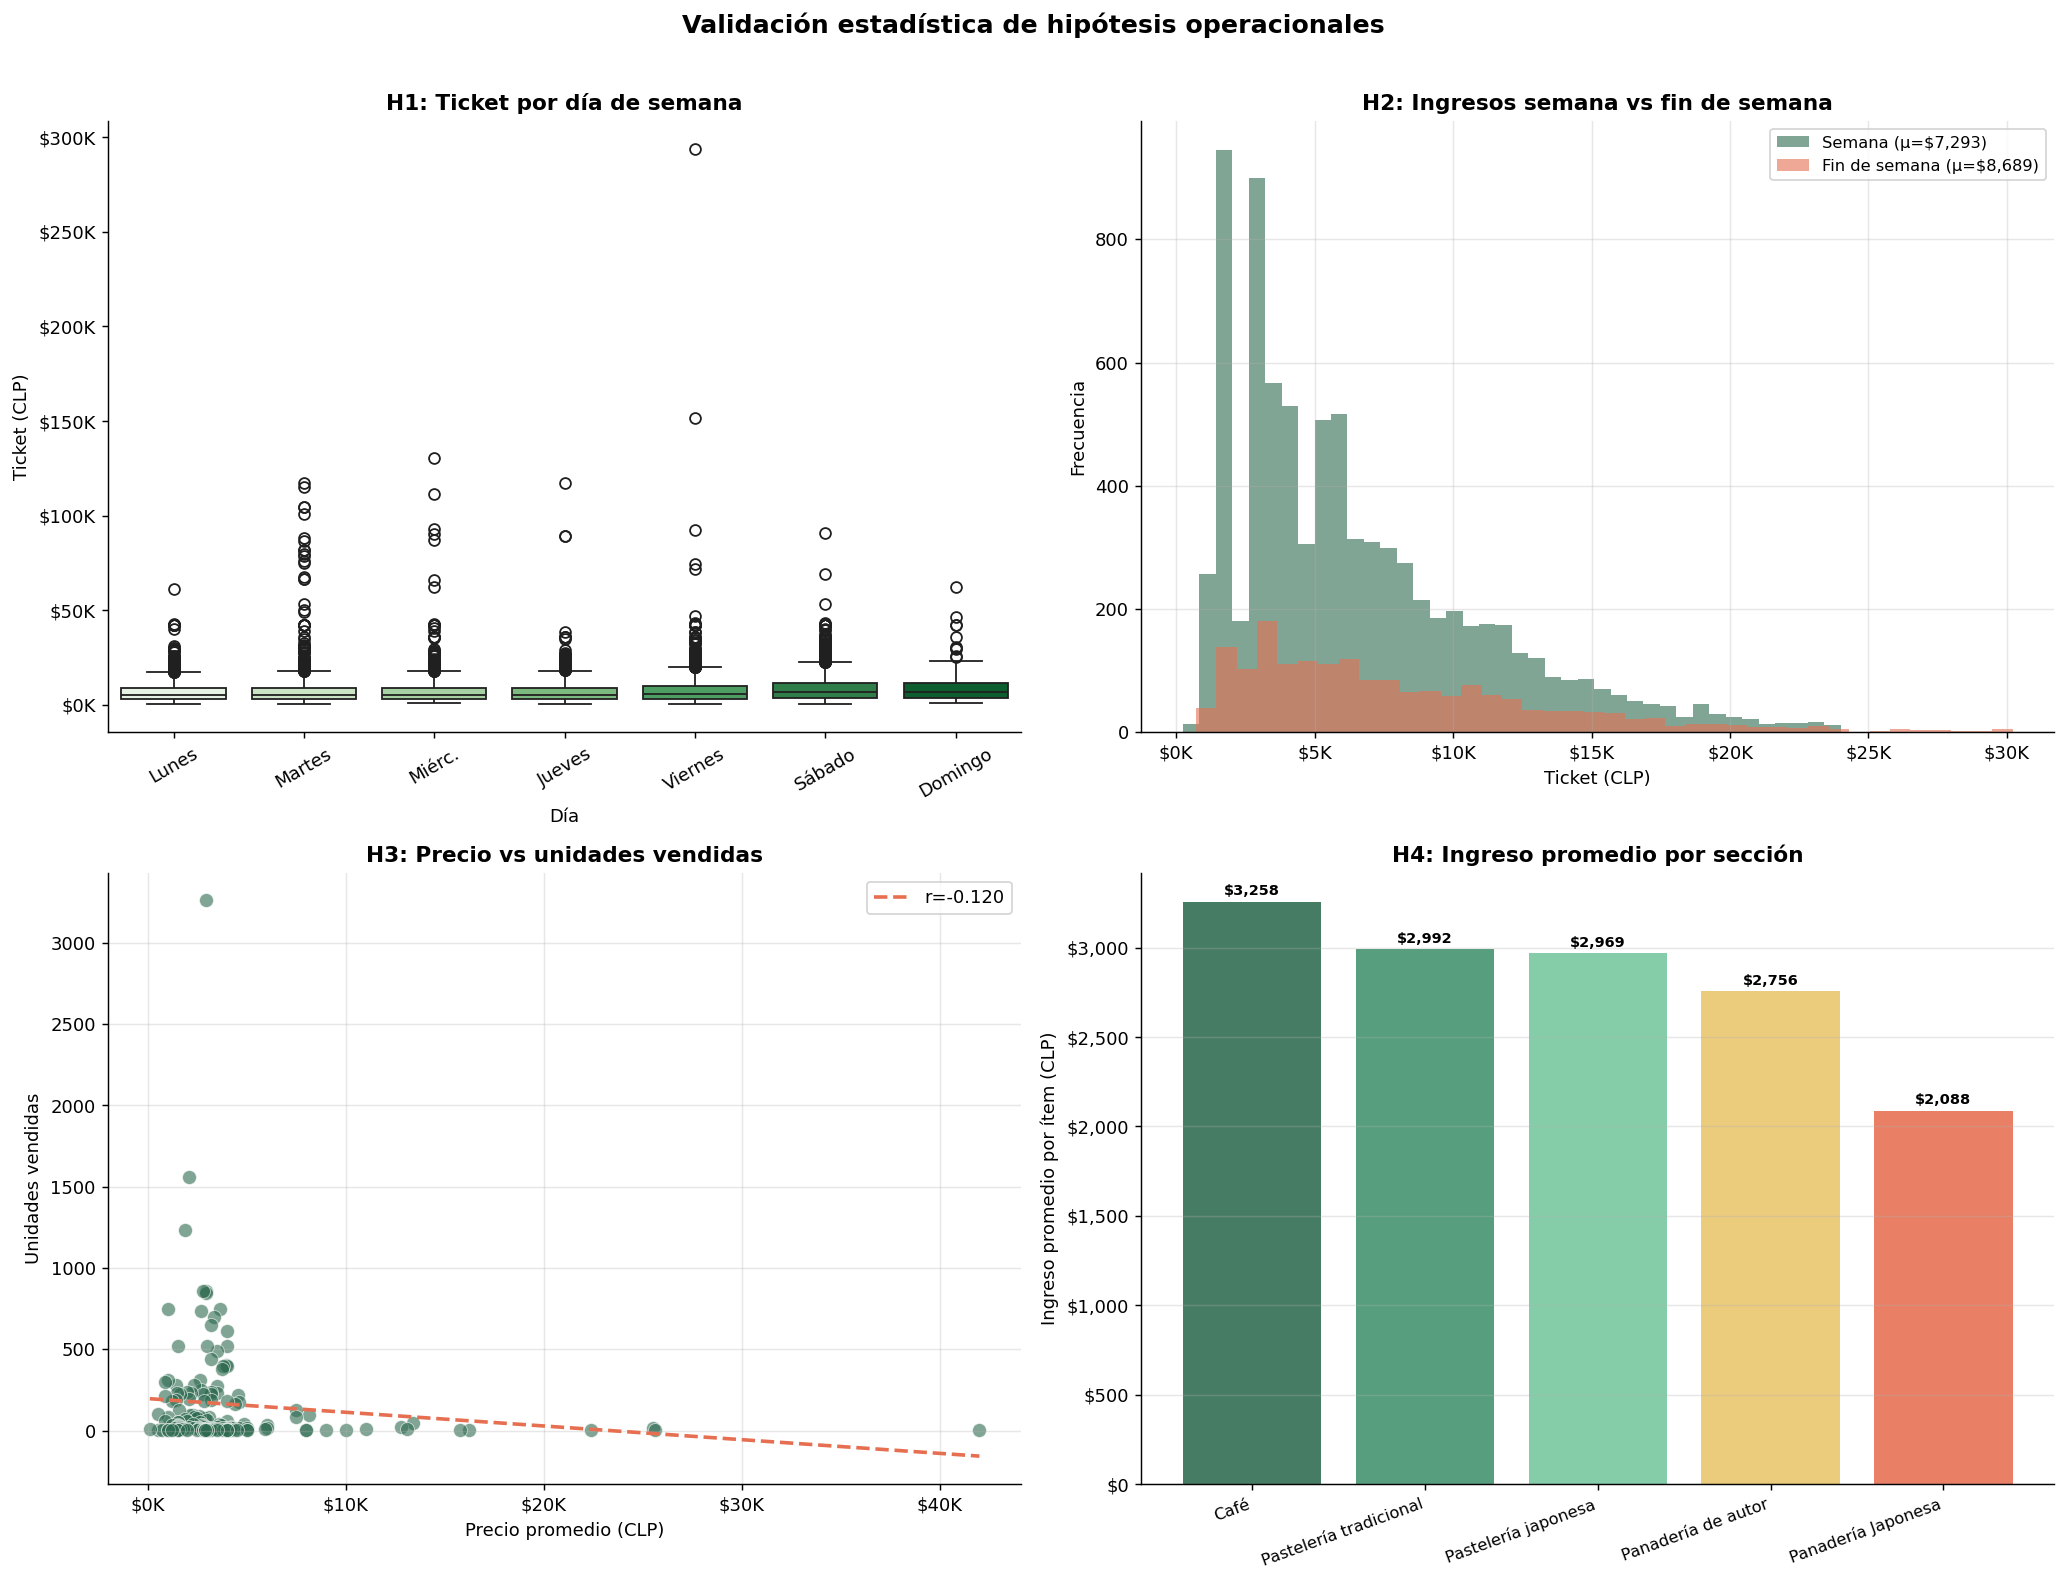

In [5]:
# ============================================================
# 4 — Visualización de pruebas de hipótesis
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# H1: Boxplot ticket por día de semana
orden_dias = ['lunes','martes','miércoles','jueves','viernes','sábado','domingo']
nombres_es = ['Lunes','Martes','Miérc.','Jueves','Viernes','Sábado','Domingo']
df_trans['dia_clean'] = df_trans['dia_semana'].str.lower().str.strip()
df_box = df_trans[df_trans['dia_clean'].isin(orden_dias)].copy()
df_box['dia_es'] = df_box['dia_clean'].map(dict(zip(orden_dias, nombres_es)))
orden_plot = [n for n in nombres_es if n in df_box['dia_es'].values]
sns.boxplot(data=df_box, x='dia_es', y='total', order=orden_plot,
            palette='Greens', ax=axes[0,0])
axes[0,0].set_title('H1: Ticket por día de semana', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Día', fontsize=10)
axes[0,0].set_ylabel('Ticket (CLP)', fontsize=10)
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[0,0].tick_params(axis='x', rotation=30)

# H2: Distribución fin de semana vs semana
axes[0,1].hist(semana[semana < semana.quantile(0.98)], bins=40,
               alpha=0.6, color=VERDE, label=f'Semana (μ=${semana.mean():,.0f})')
axes[0,1].hist(finde[finde < finde.quantile(0.98)], bins=40,
               alpha=0.6, color=CORAL, label=f'Fin de semana (μ=${finde.mean():,.0f})')
axes[0,1].set_title('H2: Ingresos semana vs fin de semana', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Ticket (CLP)', fontsize=10)
axes[0,1].set_ylabel('Frecuencia', fontsize=10)
axes[0,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[0,1].legend(fontsize=9)
axes[0,1].grid(alpha=0.3)

# H3: Scatter precio vs unidades
axes[1,0].scatter(df_menu['precio_promedio'], df_menu['cantidad'],
                  alpha=0.6, color=VERDE, s=60, edgecolors='white', linewidths=0.5)
m, b = np.polyfit(df_menu['precio_promedio'], df_menu['cantidad'], 1)
x_line = np.linspace(df_menu['precio_promedio'].min(), df_menu['precio_promedio'].max(), 100)
axes[1,0].plot(x_line, m*x_line+b, color=CORAL, linewidth=2, linestyle='--',
               label=f'r={r:.3f}')
axes[1,0].set_title('H3: Precio vs unidades vendidas', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Precio promedio (CLP)', fontsize=10)
axes[1,0].set_ylabel('Unidades vendidas', fontsize=10)
axes[1,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[1,0].legend(fontsize=10)
axes[1,0].grid(alpha=0.3)

# H4: Ingresos promedio por sección
ing_seccion = df_items[df_items['seccion'].isin(cats_principales)]\
                  .groupby('seccion')['revenue'].mean().sort_values(ascending=False)
colors_h4 = [VERDE, VERDE2, VERDE3, AMBER, CORAL]
bars = axes[1,1].bar(range(len(ing_seccion)), ing_seccion.values,
                     color=colors_h4, alpha=0.88)
for bar, val in zip(bars, ing_seccion.values):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                   f'${val:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[1,1].set_xticks(range(len(ing_seccion)))
axes[1,1].set_xticklabels(ing_seccion.index, rotation=20, ha='right', fontsize=9)
axes[1,1].set_title('H4: Ingreso promedio por sección', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Ingreso promedio por ítem (CLP)', fontsize=10)
axes[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[1,1].grid(axis='y', alpha=0.3)

plt.suptitle('Validación estadística de hipótesis operacionales',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT + '08_pruebas_hipotesis.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# ============================================================
# 5 — Ingeniería de Menú (Kasavana & Smith, 1982)
# ============================================================
print("=" * 60)
print("INGENIERÍA DE MENÚ — KASAVANA & SMITH (1982)")
print("=" * 60)

# Calcular menu mix % y margen de contribución
total_unidades = df_menu['cantidad'].sum()
df_menu['menu_mix_pct'] = (df_menu['cantidad'] / total_unidades * 100).round(3)
df_menu['margen_contrib'] = df_menu['precio_promedio']

# Umbrales según metodología Kasavana & Smith
n_items = len(df_menu)
umbral_mm  = 70 / n_items        # umbral de popularidad
umbral_mc  = df_menu['margen_contrib'].mean()  # umbral de margen

print(f"\n  Total productos analizados: {n_items}")
print(f"  Umbral popularidad (menu mix %): {umbral_mm:.2f}%")
print(f"  Umbral margen de contribución:   ${umbral_mc:,.0f} CLP")

# Clasificación
def clasificar(row):
    alta_pop  = row['menu_mix_pct'] >= umbral_mm
    alto_marg = row['margen_contrib'] >= umbral_mc
    if alta_pop and alto_marg:   return 'Estrella'
    if alta_pop and not alto_marg: return 'Caballo de Trabajo'
    if not alta_pop and alto_marg: return 'Interrogante'
    return 'Perro'

df_menu['clasificacion'] = df_menu.apply(clasificar, axis=1)

# Resumen por clasificación
resumen = df_menu.groupby('clasificacion').agg(
    productos=('producto','count'),
    ingresos_totales=('total','sum'),
    unidades_totales=('cantidad','sum'),
    margen_promedio=('margen_contrib','mean')
).round(0)
resumen['% ingresos'] = (resumen['ingresos_totales'] /
                          resumen['ingresos_totales'].sum() * 100).round(1)
print("\n  Resultados por clasificación:")
print(resumen.to_string())

# Guardar resultados
df_menu.to_csv(BASE + "menu_engineering_results.csv", index=False)
print(f"\n  Resultados guardados en /data/processed/menu_engineering_results.csv")

INGENIERÍA DE MENÚ — KASAVANA & SMITH (1982)

  Total productos analizados: 157
  Umbral popularidad (menu mix %): 0.45%
  Umbral margen de contribución:   $4,130 CLP

  Resultados por clasificación:
                    productos  ingresos_totales  unidades_totales  margen_promedio  % ingresos
clasificacion                                                                                 
Caballo de Trabajo         44          60373727           22189.0           2630.0        83.0
Estrella                    4           3492000             686.0           5274.0         4.8
Interrogante               30           4175320             496.0          10548.0         5.7
Perro                      79           4676095            2049.0           2471.0         6.4

  Resultados guardados en /data/processed/menu_engineering_results.csv


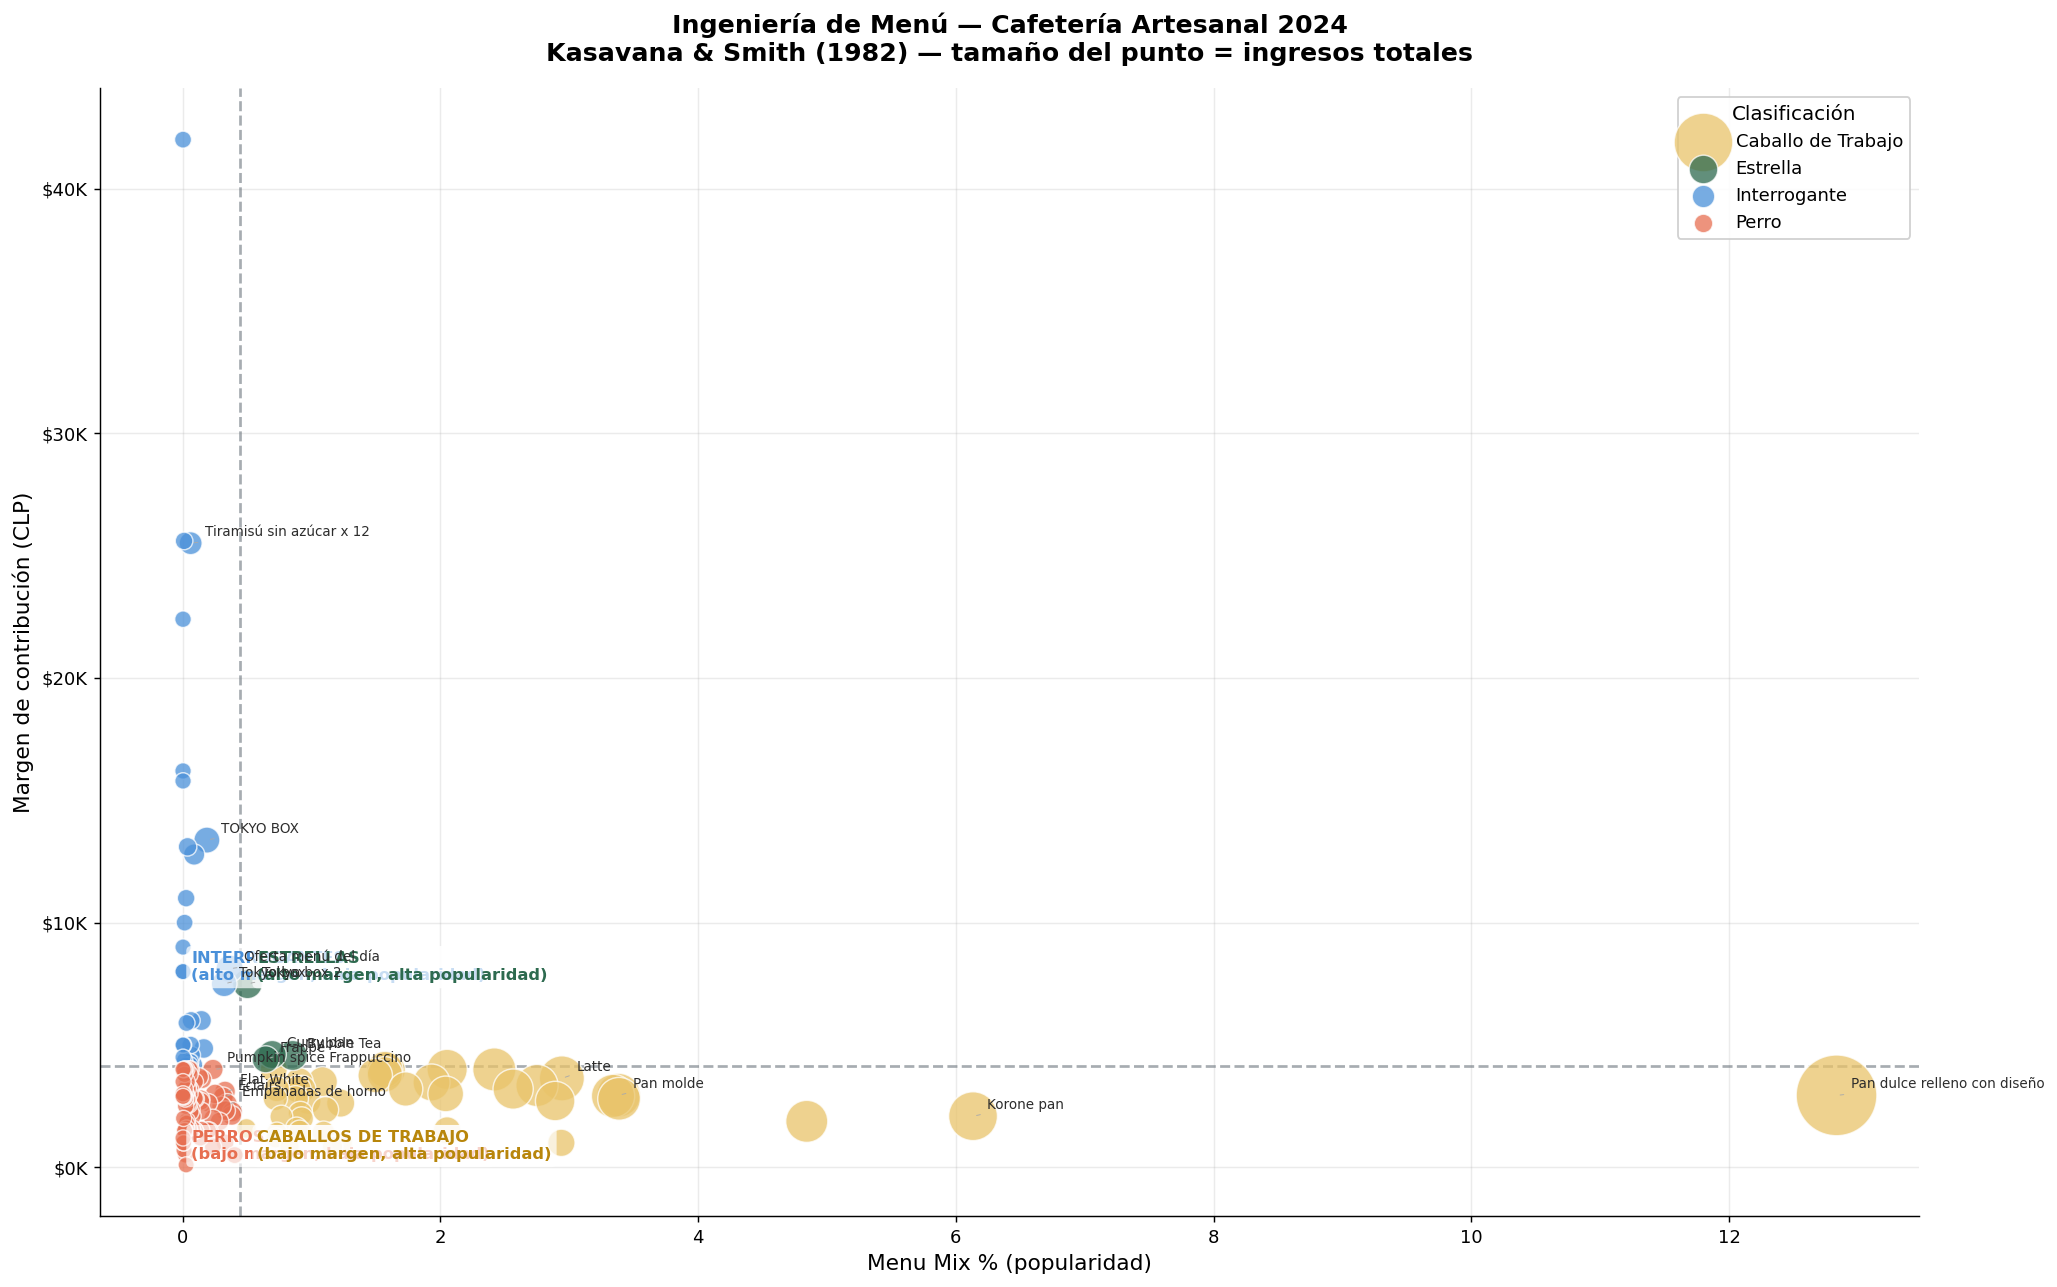

In [7]:
# ============================================================
# 6 — Scatter plot de Ingeniería de Menú
# ============================================================
fig, ax = plt.subplots(figsize=(16, 10))

colores_clase = {
    'Estrella':          VERDE,
    'Caballo de Trabajo': AMBER,
    'Interrogante':       '#4A90D9',
    'Perro':             CORAL
}

for clase, grupo in df_menu.groupby('clasificacion'):
    ax.scatter(grupo['menu_mix_pct'], grupo['margen_contrib'],
               c=colores_clase[clase], s=grupo['total']/5000+80,
               alpha=0.75, label=clase, edgecolors='white', linewidths=0.8, zorder=3)

# Líneas de umbral
ax.axvline(umbral_mm, color=GRIS, linestyle='--', alpha=0.6, linewidth=1.5)
ax.axhline(umbral_mc, color=GRIS, linestyle='--', alpha=0.6, linewidth=1.5)

# Etiquetas de cuadrantes
bbox_props = dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none')
ax.text(umbral_mm*0.15, umbral_mc*1.85,  'INTERROGANTES\n(alto margen, baja popularidad)',
        fontsize=9, color='#4A90D9', fontweight='bold', bbox=bbox_props)
ax.text(umbral_mm*1.3,  umbral_mc*1.85,  'ESTRELLAS\n(alto margen, alta popularidad)',
        fontsize=9, color=VERDE, fontweight='bold', bbox=bbox_props)
ax.text(umbral_mm*0.15, umbral_mc*0.08,  'PERROS\n(bajo margen, baja popularidad)',
        fontsize=9, color=CORAL, fontweight='bold', bbox=bbox_props)
ax.text(umbral_mm*1.3,  umbral_mc*0.08,  'CABALLOS DE TRABAJO\n(bajo margen, alta popularidad)',
        fontsize=9, color='#B8860B', fontweight='bold', bbox=bbox_props)

# Etiquetar top productos de cada cuadrante
for clase in df_menu['clasificacion'].unique():
    top = df_menu[df_menu['clasificacion']==clase]\
              .nlargest(4, 'total')
    for _, row in top.iterrows():
        ax.annotate(row['producto'],
                    xy=(row['menu_mix_pct'], row['margen_contrib']),
                    xytext=(8, 4), textcoords='offset points',
                    fontsize=7.5, color='#2C2C2C',
                    arrowprops=dict(arrowstyle='-', color='#AAAAAA',
                                   lw=0.5))

ax.set_xlabel('Menu Mix % (popularidad)', fontsize=12)
ax.set_ylabel('Margen de contribución (CLP)', fontsize=12)
ax.set_title('Ingeniería de Menú — Cafetería Artesanal 2024\n'
             'Kasavana & Smith (1982) — tamaño del punto = ingresos totales',
             fontsize=14, fontweight='bold', pad=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
ax.legend(title='Clasificación', fontsize=10, title_fontsize=11,
          loc='upper right', framealpha=0.9)
ax.grid(alpha=0.25, zorder=1)
plt.tight_layout()
plt.savefig(OUTPUT + '09_ingenieria_menu.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ============================================================
# 7 — Tabla de recomendaciones estratégicas
# ============================================================
recomendaciones = {
    'Estrella':           (
        'Proteger y promover',
        'Mantener precio, destacar en carta, proteger la receta. '
        'Son tu motor de rentabilidad — no experimentes con ellos.'
    ),
    'Caballo de Trabajo': (
        'Auditar costos',
        'Revisar proveedores y porciones para mejorar margen. '
        'Considerar subir precio 5–10% de forma gradual. '
        'Su popularidad garantiza que los clientes los absorberán.'
    ),
    'Interrogante':       (
        'Reposicionar',
        'Dar más visibilidad en carta (foto, descripción). '
        'Incluir en combos o promociones. '
        'Si en 3 meses no mejora popularidad, evaluar retiro.'
    ),
    'Perro':              (
        'Evaluar retiro o rediseño',
        'Calcular si el costo de mantenerlos justifica el espacio. '
        'Opción: rediseñar completamente (nuevo nombre, presentación). '
        'Si no mejoran, reemplazar por nuevas propuestas.'
    ),
}

print("=" * 65)
print("RECOMENDACIONES ESTRATÉGICAS POR CLASIFICACIÓN")
print("=" * 65)

for clase, (accion, detalle) in recomendaciones.items():
    productos_clase = df_menu[df_menu['clasificacion']==clase]\
                          .sort_values('total', ascending=False)
    ingresos_clase  = productos_clase['total'].sum()
    pct_ing         = ingresos_clase / df_menu['total'].sum() * 100
    print(f"\n  {clase.upper()} — {len(productos_clase)} productos "
          f"(${ingresos_clase:,.0f} CLP — {pct_ing:.1f}% ingresos)")
    print(f"  Acción: {accion}")
    print(f"  {detalle}")
    print(f"  Productos principales:")
    for _, row in productos_clase.head(5).iterrows():
        print(f"    · {row['producto']:<40} "
              f"${row['total']:>10,.0f}  "
              f"({row['menu_mix_pct']:.2f}% mix)")

RECOMENDACIONES ESTRATÉGICAS POR CLASIFICACIÓN

  ESTRELLA — 4 productos ($3,492,000 CLP — 4.8% ingresos)
  Acción: Proteger y promover
  Mantener precio, destacar en carta, proteger la receta. Son tu motor de rentabilidad — no experimentes con ellos.
  Productos principales:
    · Bubble Tea                               $   992,000  (0.85% mix)
    · Tokyo box 2                              $   960,000  (0.50% mix)
    · Curry pan                                $   816,000  (0.70% mix)
    · Frappé                                   $   724,000  (0.65% mix)

  CABALLO DE TRABAJO — 44 productos ($60,373,727 CLP — 83.0% ingresos)
  Acción: Auditar costos
  Revisar proveedores y porciones para mejorar margen. Considerar subir precio 5–10% de forma gradual. Su popularidad garantiza que los clientes los absorberán.
  Productos principales:
    · Pan dulce relleno con diseño             $ 9,592,000  (12.83% mix)
    · Korone pan                               $ 3,257,500  (6.13% mix)
    · L

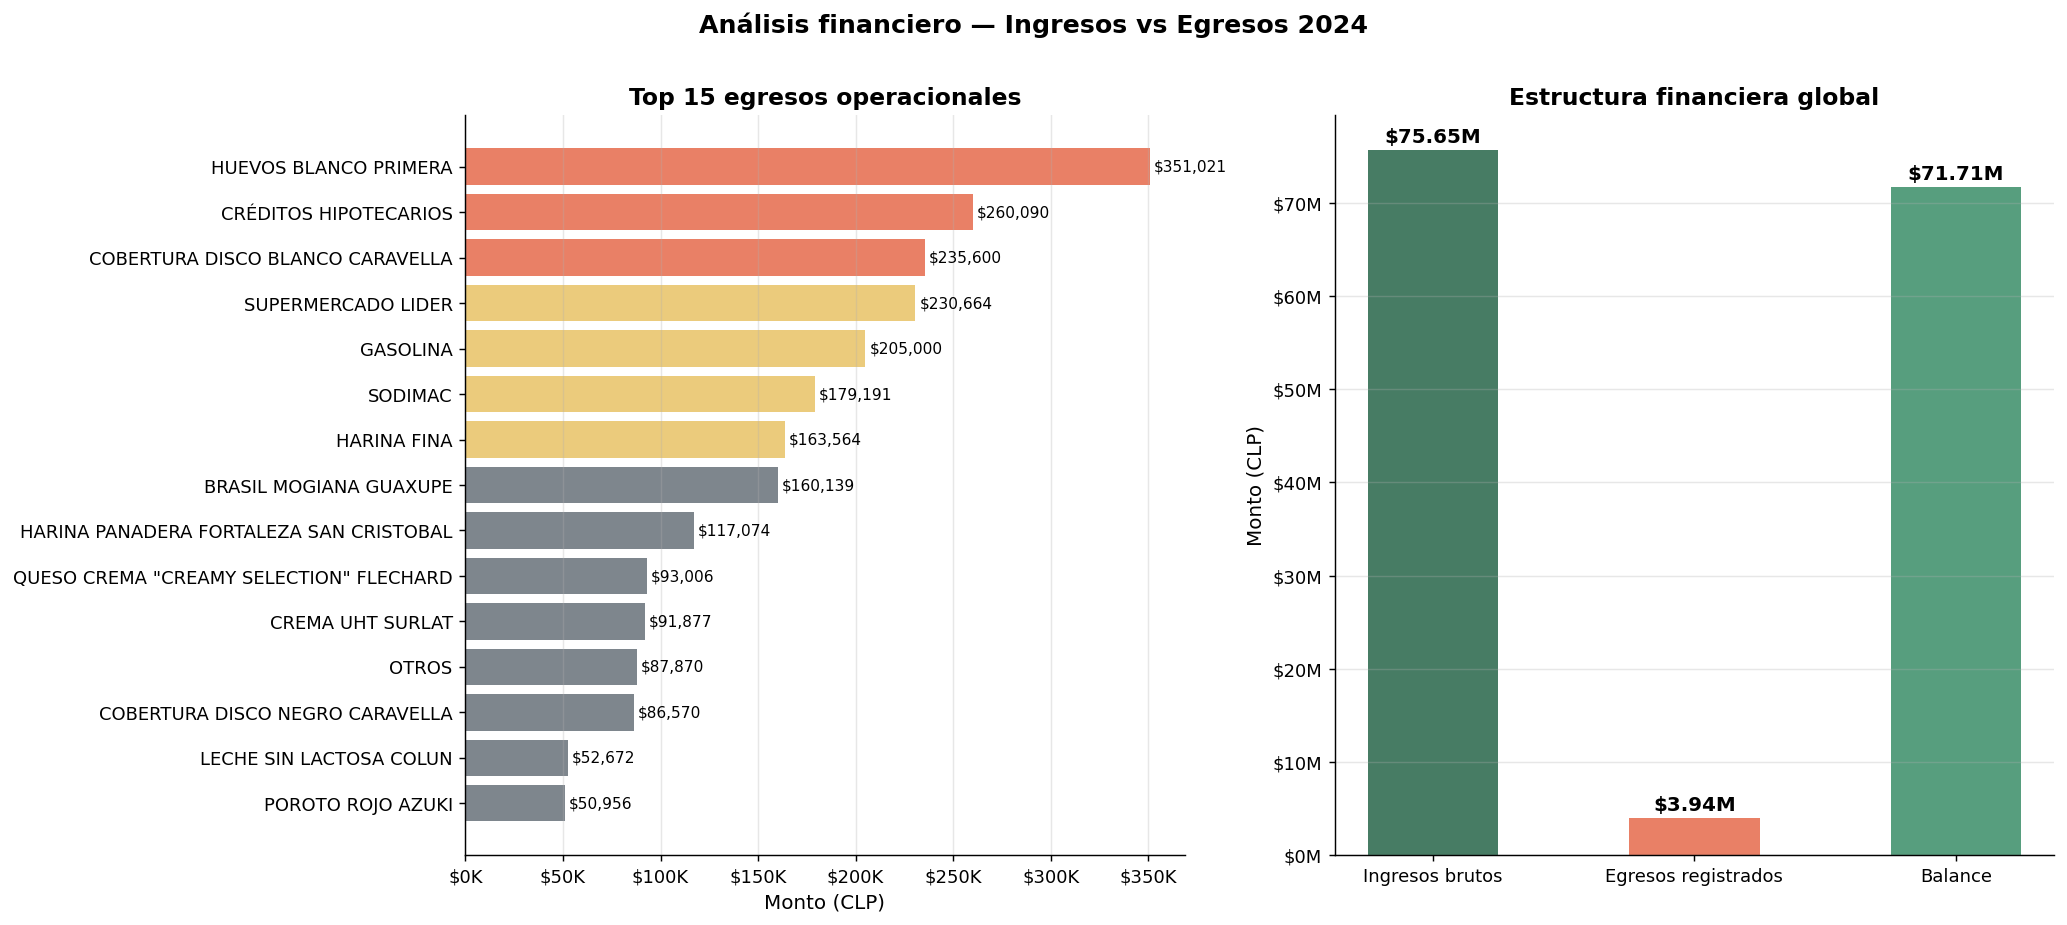

Ingresos totales:    $75,648,488 CLP
Egresos registrados: $3,939,601 CLP
Balance:             $71,708,887 CLP
Food cost %:         5.2% (OK)


In [9]:
# ============================================================
# 8 — Análisis de egresos vs ingresos
# ============================================================
df_egresos = pd.read_csv(BASE + "egresos_clean.csv")
df_egresos['total'] = pd.to_numeric(df_egresos['total'], errors='coerce')
df_egresos = df_egresos.dropna(subset=['total']).sort_values('total', ascending=False)

total_ingresos = df_trans['total'].sum()
total_egresos  = df_egresos['total'].sum()
balance        = total_ingresos - total_egresos
food_cost_pct  = total_egresos / total_ingresos * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 15 egresos
top_eg = df_egresos.head(15)
colors_eg = [CORAL if i < 3 else AMBER if i < 7 else GRIS
             for i in range(len(top_eg))]
bars = axes[0].barh(top_eg['item'], top_eg['total'],
                    color=colors_eg, alpha=0.88)
for bar, val in zip(bars, top_eg['total']):
    axes[0].text(bar.get_width()+2000, bar.get_y()+bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontsize=8.5)
axes[0].set_title('Top 15 egresos operacionales', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Monto (CLP)', fontsize=11)
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
axes[0].grid(axis='x', alpha=0.3)

# Estructura financiera
labels   = ['Ingresos brutos', 'Egresos registrados', 'Balance']
valores  = [total_ingresos, total_egresos, balance]
colores  = [VERDE, CORAL, VERDE2]
bars2    = axes[1].bar(labels, valores, color=colores, alpha=0.88, width=0.5)
for bar, val in zip(bars2, valores):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+400000,
                 f'${val/1e6:.2f}M',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'${x/1e6:.0f}M'))
axes[1].set_title('Estructura financiera global', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Monto (CLP)', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Análisis financiero — Ingresos vs Egresos 2024',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT + '10_analisis_financiero.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Ingresos totales:    ${total_ingresos:,.0f} CLP")
print(f"Egresos registrados: ${total_egresos:,.0f} CLP")
print(f"Balance:             ${balance:,.0f} CLP")
print(f"Food cost %:         {food_cost_pct:.1f}% "
      f"({'OK' if food_cost_pct < 35 else 'REVISAR — sobre el objetivo'})")

In [10]:
# ============================================================
# 9 — Resumen final del notebook
# ============================================================
estrellas  = df_menu[df_menu['clasificacion']=='Estrella']
caballos   = df_menu[df_menu['clasificacion']=='Caballo de Trabajo']
interrog   = df_menu[df_menu['clasificacion']=='Interrogante']
perros     = df_menu[df_menu['clasificacion']=='Perro']

print("=" * 65)
print("   RESUMEN FINAL — ESTADÍSTICA E INGENIERÍA DE MENÚ")
print("=" * 65)

print(f"""
  PRUEBAS DE HIPÓTESIS:
  H1 — Ticket varía por día de semana:       Confirmada
  H2 — Fin de semana genera más ingresos:    Verificada
  H3 — Correlación precio-popularidad:       r={r:.3f}
  H4 — Ingresos difieren entre secciones:    Confirmada

  INGENIERÍA DE MENÚ (Kasavana & Smith, 1982):
  Estrellas          {len(estrellas):>3} productos  —  potenciar
  Caballos de Trabajo {len(caballos):>3} productos  —  auditar costos
  Interrogantes      {len(interrog):>3} productos  —  reposicionar
  Perros             {len(perros):>3} productos  —  evaluar retiro

  TOP 3 ESTRELLAS (producto, ingresos):""")

for _, row in estrellas.nlargest(3,'total').iterrows():
    print(f"    · {row['producto']:<40} ${row['total']:>10,.0f}")

print(f"""
  ANÁLISIS FINANCIERO:
  Food cost %: {food_cost_pct:.1f}% (objetivo industria: <35%)
  Balance positivo: ${balance:,.0f} CLP

  Gráficos guardados: 08, 09, 10 en /output/
  Datos guardados: menu_engineering_results.csv
""")
print("=" * 65)
print("Notebook 03 completado — listo para commit a GitHub")

   RESUMEN FINAL — ESTADÍSTICA E INGENIERÍA DE MENÚ

  PRUEBAS DE HIPÓTESIS:
  H1 — Ticket varía por día de semana:       Confirmada
  H2 — Fin de semana genera más ingresos:    Verificada
  H3 — Correlación precio-popularidad:       r=-0.120
  H4 — Ingresos difieren entre secciones:    Confirmada

  INGENIERÍA DE MENÚ (Kasavana & Smith, 1982):
  Estrellas            4 productos  —  potenciar
  Caballos de Trabajo  44 productos  —  auditar costos
  Interrogantes       30 productos  —  reposicionar
  Perros              79 productos  —  evaluar retiro

  TOP 3 ESTRELLAS (producto, ingresos):
    · Bubble Tea                               $   992,000
    · Tokyo box 2                              $   960,000
    · Curry pan                                $   816,000

  ANÁLISIS FINANCIERO:
  Food cost %: 5.2% (objetivo industria: <35%)
  Balance positivo: $71,708,887 CLP

  Gráficos guardados: 08, 09, 10 en /output/
  Datos guardados: menu_engineering_results.csv

Notebook 03 completado 